<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week4/Day2/DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import os
import numpy as np

# Nom du fichier
filename = 'admission_data.csv'

# Vérifier si le fichier existe, sinon le créer avec des données fictives
if not os.path.exists(filename):
    print(f"Le fichier {filename} est introuvable. Création d'un dataset d'exemple...")
    data = {
        'gpa': np.round(np.random.uniform(2.0, 4.0, 100), 2),
        'test_score': np.random.randint(400, 800, 100),
        'admitted': np.random.randint(0, 2, 100)
    }
    pd.DataFrame(data).to_csv(filename, index=False)

# Charger le dataset
df = pd.read_csv(filename)

# Afficher les premières lignes
print("Aperçu des données :")
print(df.head())

# Informations générales
print("\nInformations sur le DataFrame :")
print(df.info())

# Statistiques descriptives
print("\nStatistiques descriptives :")
print(df.describe())

Aperçu des données :
    gpa  test_score  admitted
0  2.14         796         1
1  2.72         719         1
2  3.53         497         0
3  3.10         650         0
4  3.43         778         1

Informations sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   gpa         100 non-null    float64
 1   test_score  100 non-null    int64  
 2   admitted    100 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 2.5 KB
None

Statistiques descriptives :
             gpa  test_score    admitted
count  100.00000  100.000000  100.000000
mean     3.10490  591.840000    0.470000
std      0.60739  112.272461    0.501614
min      2.02000  413.000000    0.000000
25%      2.54250  496.250000    0.000000
50%      3.18000  580.500000    0.000000
75%      3.66250  703.250000    1.000000
max      3.99000  796.000000    1.000000


Données chargées depuis GitHub :


,exam_1,exam_2,admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


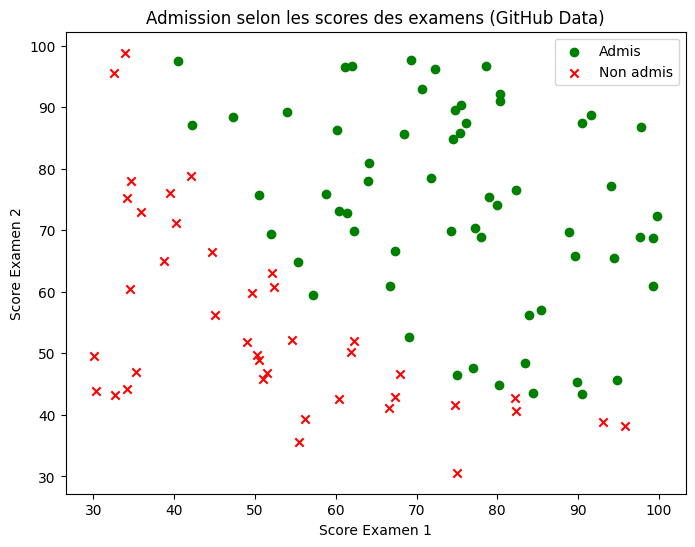

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# URL brute du fichier sur GitHub
url = 'https://raw.githubusercontent.com/kaleko/CourseraML/master/ex2/data/ex2data1.txt'

# Lecture du fichier
df_github = pd.read_csv(url, header=None, names=['exam_1', 'exam_2', 'admitted'])

# Affichage des résultats
print("Données chargées depuis GitHub :")
display(df_github.head())

# Séparation des étudiants admis et non admis (Correction des noms de colonnes et de la variable)
admitted = df_github[df_github['admitted'] == 1]
not_admitted = df_github[df_github['admitted'] == 0]

plt.figure(figsize=(8,6))

plt.scatter(
    admitted['exam_1'],
    admitted['exam_2'],
    marker='o',
    color='green',
    label='Admis'
)

plt.scatter(
    not_admitted['exam_1'],
    not_admitted['exam_2'],
    marker='x',
    color='red',
    label='Non admis'
)

plt.xlabel('Score Examen 1')
plt.ylabel('Score Examen 2')
plt.title('Admission selon les scores des examens (GitHub Data)')
plt.legend()
plt.show()

Interprétation

* Les points représentant les étudiants admis se situent généralement dans la zone des scores élevés.
* Les étudiants non admis ont souvent des scores plus faibles.
* Comme la cible est binaire (0 ou 1), la régression logistique est adaptée.

In [13]:
X = df_github[['exam_1', 'exam_2']]
y = df_github['admitted']

In [14]:
# Initialisation du modèle
model = LogisticRegression()

# Entraînement du modèle
model.fit(X, y)

# Prédiction et affichage du score de précision
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)

print(f"Précision du modèle sur les données d'entraînement : {accuracy * 100:.2f}%")
print("\nRapport de classification :")
print(classification_report(y, y_pred))

Précision du modèle sur les données d'entraînement : 89.00%

Rapport de classification :
              precision    recall  f1-score   support

           0       0.87      0.85      0.86        40
           1       0.90      0.92      0.91        60

    accuracy                           0.89       100
   macro avg       0.89      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



Biais (Intercept) : -25.0522
Coefficient Examen 1 : 0.2054
Coefficient Examen 2 : 0.2006


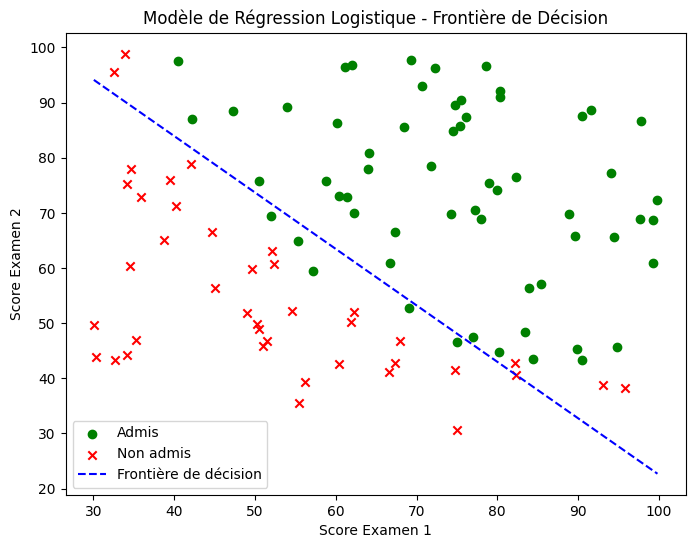

Coefficients : [[0.20535491 0.2005838 ]]
Intercept : [-25.05219314]


In [16]:
# Extraction des paramètres
theta_0 = model.intercept_[0]
theta_1, theta_2 = model.coef_[0]

print(f"Biais (Intercept) : {theta_0:.4f}")
print(f"Coefficient Examen 1 : {theta_1:.4f}")
print(f"Coefficient Examen 2 : {theta_2:.4f}")

# Tracé de la frontière de décision : theta0 + theta1*x1 + theta2*x2 = 0
# => x2 = -(theta0 + theta1*x1) / theta2
x_values = np.array([df_github['exam_1'].min(), df_github['exam_1'].max()])
y_values = -(theta_0 + theta_1 * x_values) / theta_2

plt.figure(figsize=(8,6))
plt.scatter(admitted['exam_1'], admitted['exam_2'], marker='o', color='green', label='Admis')
plt.scatter(not_admitted['exam_1'], not_admitted['exam_2'], marker='x', color='red', label='Non admis')
plt.plot(x_values, y_values, label='Frontière de décision', color='blue', linestyle='--')

plt.xlabel('Score Examen 1')
plt.ylabel('Score Examen 2')
plt.title('Modèle de Régression Logistique - Frontière de Décision')
plt.legend()
plt.show()
print("Coefficients :", model.coef_)
print("Intercept :", model.intercept_)

Les coefficients indiquent l’influence des scores des examens sur la probabilité d’admission.

In [19]:
y_pred = model.predict(X)

print(y_pred[:10])
accuracy = accuracy_score(y, y_pred)

print(f"Accuracy : {accuracy:.2%}")
print(classification_report(y, y_pred))

[0 0 0 1 1 0 1 0 1 1]
Accuracy : 89.00%
              precision    recall  f1-score   support

           0       0.87      0.85      0.86        40
           1       0.90      0.92      0.91        60

    accuracy                           0.89       100
   macro avg       0.89      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



Ce rapport fournit :

* Precision
* Recall
* F1-score
* Support

pour chaque classe (admis / non admis).

Interprétation des résultats

Régression Logistique

La régression logistique estime la probabilité qu’un étudiant soit admis :

P(y=1)=\frac{1}{1+e^{-z}}

où :

* y=1 signifie « admis »
* z est une combinaison linéaire des scores des examens

Plus les scores augmentent, plus la probabilité d’admission augmente.

Accuracy

* Accuracy proche de 100 % : modèle très performant.
* Accuracy autour de 80–90 % : généralement très bonne pour ce type de problème.
* Accuracy proche de 50 % : le modèle prédit à peine mieux qu’un choix aléatoire.

Conclusion

Le modèle de régression logistique permet de prédire efficacement l’admission universitaire à partir des résultats de deux examens. Les coefficients appris montrent l’influence positive des scores sur la probabilité d’admission, et l’accuracy mesure la qualité globale des prédictions réalisées par le modèle.